# 차체 도장 불량 데이터 분석


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

CLASS_NAMES = [
    'Bodypanel-Dent', 'Front-Windscreen-Damage', 'Headlight-Damage',
    'Rear-windscreen-Damage', 'RunningBoard-Dent', 'Sidemirror-Damage',
    'Signlight-Damage', 'Taillight-Damage', 'bonnet-dent', 'boot-dent',
    'doorouter-dent', 'fender-dent', 'front-bumper-dent', 'pillar-dent',
    'quaterpanel-dent', 'rear-bumper-dent', 'roof-dent'
]

## 1. 클래스별 데이터 현황

In [5]:
label_dir = Path('data/train/labels')
counts = {i: 0 for i in range(len(CLASS_NAMES))}

for label_file in label_dir.glob('*.txt'):
    for line in label_file.read_text().strip().splitlines():
        parts = line.strip().split()
        if parts and parts[0].isdigit():
            counts[int(parts[0])] += 1

df_class = pd.DataFrame({
    '클래스': CLASS_NAMES,
    '수량': list(counts.values())
}).sort_values('수량', ascending=False).reset_index(drop=True)

df_class

,클래스,수량
0,front-bumper-dent,3797
1,doorouter-dent,3370
2,bonnet-dent,2269
3,rear-bumper-dent,2191
4,fender-dent,2003
5,quaterpanel-dent,1915
6,Headlight-Damage,1126
7,roof-dent,1073
8,Taillight-Damage,1057
9,Rear-windscreen-Damage,1019


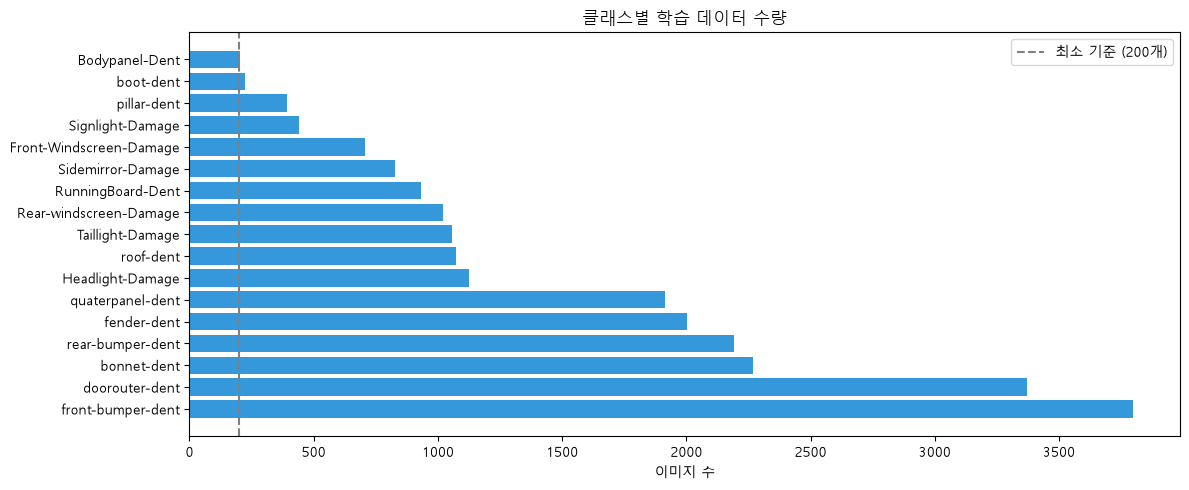

총 클래스: 17종 / 총 라벨: 23,543개


In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#e74c3c' if v < 200 else '#3498db' for v in df_class['수량']]
ax.barh(df_class['클래스'], df_class['수량'], color=colors)
ax.axvline(200, color='gray', linestyle='--', label='최소 기준 (200개)')
ax.set_title('클래스별 학습 데이터 수량')
ax.set_xlabel('이미지 수')
ax.legend()
plt.tight_layout()
plt.savefig('runs/train_3/class_distribution.png', dpi=150)
plt.show()
print(f'총 클래스: {len(CLASS_NAMES)}종 / 총 라벨: {sum(counts.values()):,}개')

## 2. 학습 결과 비교 (1차 vs 3차)

In [7]:
df1 = pd.read_csv('runs/train_1/results.csv')
df3 = pd.read_csv('runs/train_3/results.csv')
df1.columns = df1.columns.str.strip()
df3.columns = df3.columns.str.strip()

b1 = df1.loc[df1['metrics/mAP50(B)'].idxmax()]
b3 = df3.loc[df3['metrics/mAP50(B)'].idxmax()]

df_compare = pd.DataFrame({
    '구분':      ['1차 (원본 3,325장)', '3차 (병합 14,920장)'],
    'mAP50':    [round(b1['metrics/mAP50(B)'], 4), round(b3['metrics/mAP50(B)'], 4)],
    'Precision':[round(b1['metrics/precision(B)'], 4), round(b3['metrics/precision(B)'], 4)],
    'Recall':   [round(b1['metrics/recall(B)'], 4), round(b3['metrics/recall(B)'], 4)],
    'Best Epoch':[int(b1['epoch']), int(b3['epoch'])]
})
df_compare

,구분,mAP50,Precision,Recall,Best Epoch
0,"1차 (원본 3,325장)",0.4427,0.5311,0.4653,41
1,"3차 (병합 14,920장)",0.5883,0.6466,0.5366,50


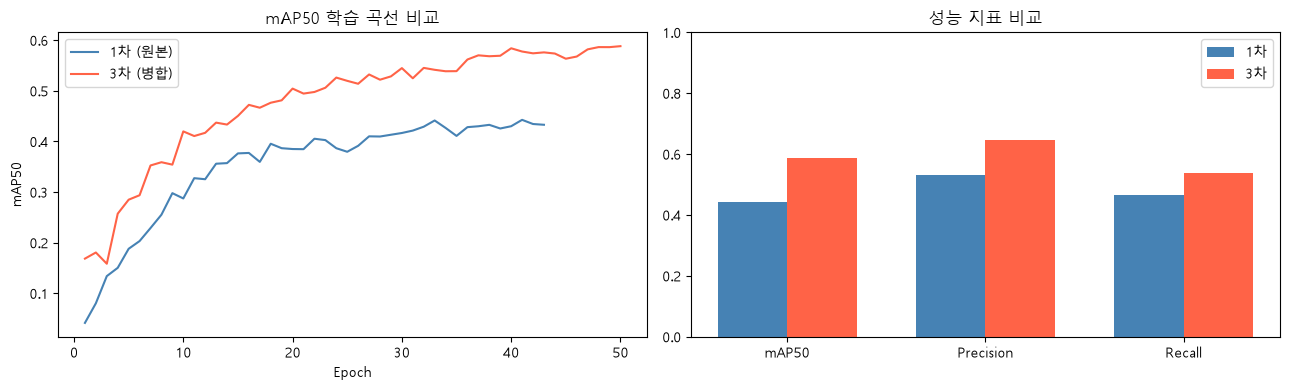

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(df1['epoch'], df1['metrics/mAP50(B)'], label='1차 (원본)', color='steelblue')
axes[0].plot(df3['epoch'], df3['metrics/mAP50(B)'], label='3차 (병합)', color='tomato')
axes[0].set_title('mAP50 학습 곡선 비교')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('mAP50')
axes[0].legend()

metrics = ['mAP50', 'Precision', 'Recall']
x = range(len(metrics))
w = 0.35
axes[1].bar([i - w/2 for i in x], df_compare.iloc[0][metrics], width=w, label='1차', color='steelblue')
axes[1].bar([i + w/2 for i in x], df_compare.iloc[1][metrics], width=w, label='3차', color='tomato')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(metrics)
axes[1].set_title('성능 지표 비교')
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.savefig('runs/train_3/compare_chart.png', dpi=150)
plt.show()

## 3. 혼동 행렬

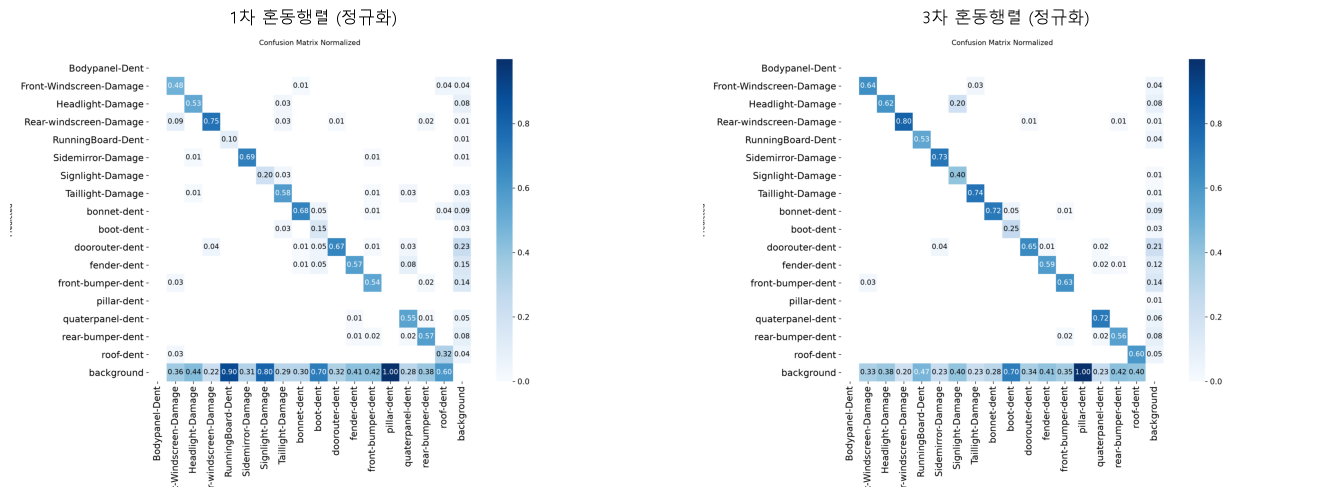

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, path, title in zip(axes,
    ['runs/train_1/confusion_matrix_normalized.png',
     'runs/train_3/confusion_matrix_normalized.png'],
    ['1차 혼동행렬 (정규화)', '3차 혼동행렬 (정규화)']):
    img = mpimg.imread(path)
    ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 4. 실제 테스트셋 추론 기반 불량률 분석 (생산 배치 시뮬레이션)

테스트셋(80장)에 실제 모델을 돌려 검출 결과를 얻고, 5장 단위 배치로 묶어 생산 라인 검사 배치처럼 시각화합니다.
(이전 버전은 `np.random`으로 만든 가상 데이터였으나, 실제 추론 결과로 교체함)

In [ ]:
from ultralytics import YOLO

MODEL_PATH = 'runs/train_3/weights/best.pt'
TEST_IMG_DIR = Path('data/test/images')

model = YOLO(MODEL_PATH)
test_images = sorted(TEST_IMG_DIR.glob('*.jpg')) + sorted(TEST_IMG_DIR.glob('*.png'))

defect_counts = []
for img_path in test_images:
    res = model.predict(str(img_path), conf=0.3, verbose=False)
    defect_counts.append(len(res[0].boxes))

BATCH_SIZE = 5
n_batches = -(-len(defect_counts) // BATCH_SIZE)  # ceil

batch_total, batch_defect = [], []
for i in range(n_batches):
    chunk = defect_counts[i * BATCH_SIZE:(i + 1) * BATCH_SIZE]
    batch_total.append(len(chunk))
    batch_defect.append(sum(1 for c in chunk if c > 0))

df_line = pd.DataFrame({
    '배치':    [f'Batch {i+1}' for i in range(n_batches)],
    '검사수': batch_total,
    '불량수': batch_defect
})
df_line['불량률(%)'] = (df_line['불량수'] / df_line['검사수'] * 100).round(2)
df_line.head(10)

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

axes[0].plot(df_line['배치'], df_line['불량률(%)'], marker='o', color='tomato', linewidth=2)
axes[0].axhline(df_line['불량률(%)'].mean(), color='gray', linestyle='--',
                label=f"평균 {df_line['불량률(%)'].mean():.1f}%")
axes[0].set_title('배치별 불량률 추이 (실제 모델 추론)')
axes[0].set_ylabel('불량률 (%)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(df_line['배치'], df_line['불량수'], color='salmon')
axes[1].set_title('배치별 불량 발생 수 (실제 모델 추론)')
axes[1].set_ylabel('불량 건수')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('runs/train_3/defect_trend.png', dpi=150)
plt.show()

print('=== 불량률 통계 요약 (실제 테스트셋 추론) ===')
print(df_line['불량률(%)'].describe().round(2))
print(f"\n총 검사: {df_line['검사수'].sum()}건")
print(f"총 불량: {df_line['불량수'].sum()}건")
print(f"전체 불량률: {df_line['불량수'].sum() / df_line['검사수'].sum() * 100:.2f}%")